In [8]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras import Input


**Google colab link for the exercise:** https://colab.research.google.com/drive/1tgeaEcbCuWyV3ggC6-ZjtEeOmuePKmQA?usp=sharing

**MNIST Dataset description**

The MNIST dataset (Modified National Institute of Standards and Technology) is a widely used benchmark in machine learning and computer vision, containing grayscale images of handwritten digits ranging from 0 to 9.

Each image is 28×28 pixels, representing a single digit in grayscale with pixel intensity values ranging from 0 (black) to 255 (white), often normalized to the range [0,1] before training.

The dataset consists of 60,000 images in the training set and 10,000 images in the test set, making it suitable for evaluating classification models. Each image is paired with a label indicating the digit it represents, either as an integer (0–9) or in one-hot encoded form.

MNIST’s simplicity, small size, and well-defined structure make it a standard starting point for beginners to practice image preprocessing, neural network design, and performance evaluation, as well as a common baseline for researchers testing new model architectures.


In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data() #load the dataset
x_train = x_train.astype("float32") / 255.0 #normalise the dataset
x_test  = x_test.astype("float32") / 255.0 #Normalise test datset

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Display sample image

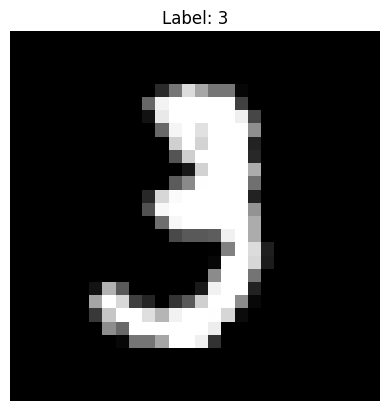

In [5]:
# Pick a sample index
sample_idx = 10 #change this value to check some other image

# Display the image
plt.imshow(x_train[sample_idx], cmap='gray')
plt.title(f"Label: {y_train[sample_idx]}")
plt.axis('off')
plt.show()

In [14]:
model = Sequential([
    Input(shape=(28, 28)),
    Flatten(),
    Dense(256, activation="relu"),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])

In [15]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 218,058 (851.79 KB)

 Trainable params: 218,058 (851.79 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",  # <— sparse loss
    metrics=["accuracy"]
)

In [17]:
model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=10, batch_size=128)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8485 - loss: 0.5200 - val_accuracy: 0.9602 - val_loss: 0.1287
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9656 - loss: 0.1137 - val_accuracy: 0.9719 - val_loss: 0.0948
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9788 - loss: 0.0713 - val_accuracy: 0.9780 - val_loss: 0.0738
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.9860 - loss: 0.0465 - val_accuracy: 0.9778 - val_loss: 0.0717
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9888 - loss: 0.0368 - val_accuracy: 0.9802 - val_loss: 0.0662
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9915 - loss: 0.0265 - val_accuracy: 0.9783 - val_loss: 0.0724
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9932 - loss: 0.0228 - val_accuracy: 0.9775 - val_loss: 0.0742
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9945 - loss: 0.0178 - val_accuracy: 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


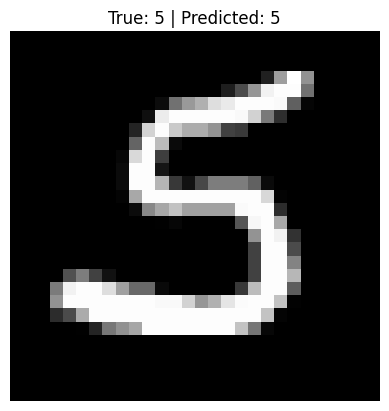

Prediction probabilities: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [19]:
# Pick a random index
idx = np.random.randint(0, len(x_test))

# Get image and true label
img = x_test[idx]
true_label = y_test[idx]

# Model prediction
pred_probs = model.predict(np.expand_dims(img, axis=0))  # shape (1, 28, 28)
pred_label = np.argmax(pred_probs)

# Show image
plt.imshow(img, cmap='gray')
plt.title(f"True: {true_label} | Predicted: {pred_label}")
plt.axis('off')
plt.show()

print("Prediction probabilities:", np.round(pred_probs[0], 3))

**Adding dropout layer in the architecture **

In [20]:
model = Sequential([
    Input(shape=(28, 28)),
    Flatten(),
    Dense(256, activation="relu"),
    Dropout(0.2),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(10, activation="softmax")
])

In [21]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 218,058 (851.79 KB)

 Trainable params: 218,058 (851.79 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",  # <— sparse loss
    metrics=["accuracy"]
)

In [23]:
model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=10, batch_size=128)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.7970 - loss: 0.6656 - val_accuracy: 0.9567 - val_loss: 0.1391
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9507 - loss: 0.1667 - val_accuracy: 0.9666 - val_loss: 0.1076
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9645 - loss: 0.1172 - val_accuracy: 0.9732 - val_loss: 0.0875
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9715 - loss: 0.0951 - val_accuracy: 0.9764 - val_loss: 0.0767
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9775 - loss: 0.0745 - val_accuracy: 0.9784 - val_loss: 0.0687
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9806 - loss: 0.0619 - val_accuracy: 0.9807 - val_loss: 0.0629
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9824 - loss: 0.0560 - val_accuracy: 0.9805 - val_loss: 0.0631
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9846 - loss: 0.0482 - val_accuracy:

**Develop a Neural Network Architecture for classification of Fashion MNIST dataset**

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


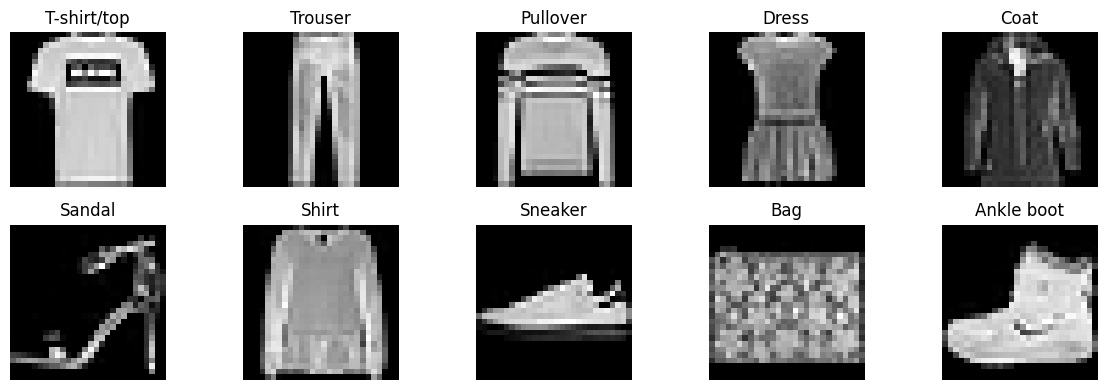

In [24]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.datasets import fashion_mnist

# Class names for Fashion-MNIST
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

# Load data
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Find one example per class
sample_images = []
for class_id in range(10):
    idx = np.where(y_train == class_id)[0][0]  # first index of that class
    sample_images.append((x_train[idx], class_names[class_id]))

# Plot
plt.figure(figsize=(12, 4))
for i, (img, label) in enumerate(sample_images):
    plt.subplot(2, 5, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(label)
    plt.axis('off')

plt.tight_layout()
plt.show()
